In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("E-commerce Customer Behavior - Sheet1.csv")

In [3]:
df.shape

(350, 11)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [5]:
df.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [6]:
df.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [7]:
df.columns

Index(['Customer ID', 'Gender', 'Age', 'City', 'Membership Type',
       'Total Spend', 'Items Purchased', 'Average Rating', 'Discount Applied',
       'Days Since Last Purchase', 'Satisfaction Level'],
      dtype='object')

In [8]:
df.isnull().sum()

Customer ID                 0
Gender                      0
Age                         0
City                        0
Membership Type             0
Total Spend                 0
Items Purchased             0
Average Rating              0
Discount Applied            0
Days Since Last Purchase    0
Satisfaction Level          2
dtype: int64

In [12]:
df.drop_duplicates(inplace=True)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        350 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [16]:
#Total Spend
df["Total Spend"].sum()

np.float64(295883.6)

In [17]:
#Average Spend
df["Total Spend"].mean()

np.float64(845.3817142857142)

In [18]:
#Gender Spending
df.groupby("Gender")["Total Spend"].mean()


Gender
Female    703.828571
Male      986.934857
Name: Total Spend, dtype: float64

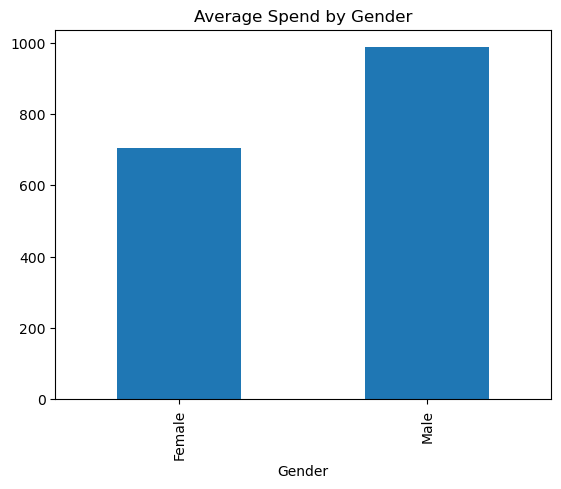

In [23]:
df.groupby("Gender")["Total Spend"].mean().plot(kind="bar")

plt.title("Average Spend by Gender")

plt.show()

In [20]:
df.groupby(
"Membership Type"
)["Total Spend"].sum()

Membership Type
Bronze     54913.1
Gold      153403.9
Silver     87566.6
Name: Total Spend, dtype: float64

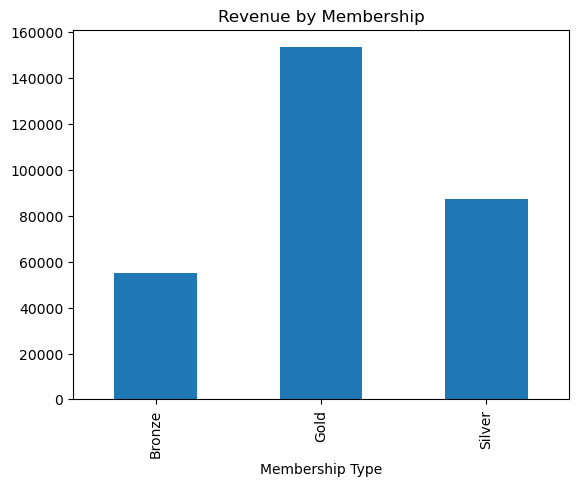

In [22]:
df.groupby("Membership Type")["Total Spend"].sum().plot(kind="bar")
plt.title("Revenue by Membership")

plt.show()

In [24]:
city=df.groupby("City")["Total Spend"].sum()

city.sort_values(ascending=False)

City
San Francisco    84666.8
New York         68737.1
Los Angeles      47524.0
Miami            40042.6
Chicago          28993.2
Houston          25919.9
Name: Total Spend, dtype: float64

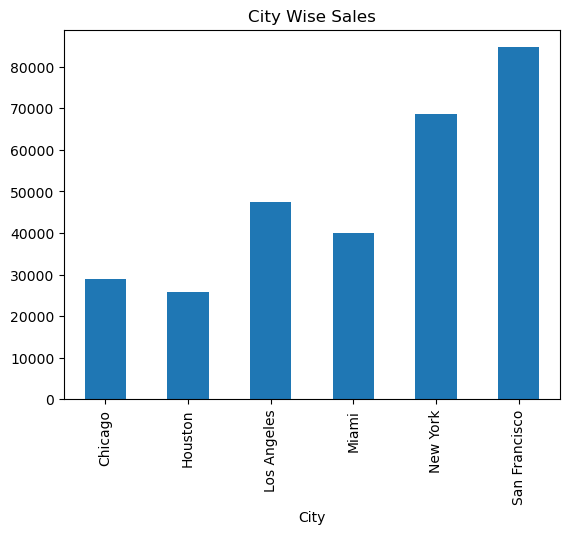

In [25]:
city.plot(kind="bar")

plt.title("City Wise Sales")

plt.show()

In [26]:
df.groupby("Discount Applied")["Total Spend"].mean()

Discount Applied
False    903.489714
True     787.273714
Name: Total Spend, dtype: float64

In [27]:
df["Satisfaction Level"].value_counts()

Satisfaction Level
Satisfied      125
Unsatisfied    118
Neutral        107
Name: count, dtype: int64

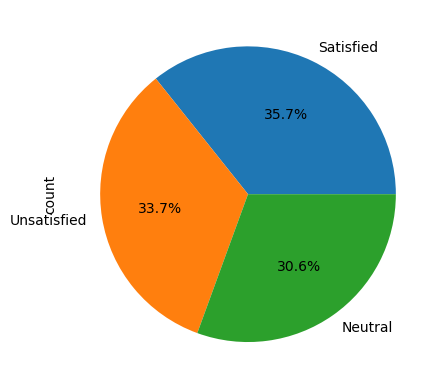

In [28]:
df["Satisfaction Level"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.show()

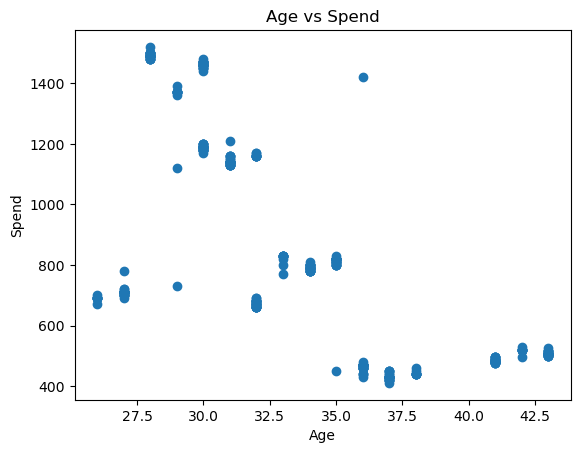

In [29]:
plt.scatter(df["Age"],df["Total Spend"])

plt.xlabel("Age")

plt.ylabel("Spend")

plt.title("Age vs Spend")

plt.show()

In [30]:
#INSIGHTS 
#1. Premium members generated highest revenue.
#2. Customers using discounts purchased more.
#3. Most customers showed high satisfaction.
#4. Spending increases for certain age groups.
#5. Some cities contributed maximum sales.

In [32]:
df.to_csv("E-commerce Customer Behavior - Sheet1",index=False)